In [1]:
import pandas as pd

data = {
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "score": [45, 50, 55, 60, 65, 70, 76, 82, 88, 93]
}

df = pd.DataFrame(data)
df

,study_hours,score
0,1,45
1,2,50
2,3,55
3,4,60
4,5,65
5,6,70
6,7,76
7,8,82
8,9,88
9,10,93


In [2]:
X = df[["study_hours"]]
y = df["score"]

print(X)
print(y)

   study_hours
0            1
1            2
2            3
3            4
4            5
5            6
6            7
7            8
8            9
9           10
0    45
1    50
2    55
3    60
4    65
5    70
6    76
7    82
8    88
9    93
Name: score, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("训练集 X：")
print(X_train)

print("测试集 X：")
print(X_test)

训练集 X：
   study_hours
5            6
0            1
7            8
2            3
9           10
4            5
3            4
6            7
测试集 X：
   study_hours
8            9
1            2


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5.34]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.85
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [6]:
y_pred = model.predict(X_test)

print("真实分数：", [int(x) for x in y_test])
print("预测分数：", [round(float(x), 2) for x in y_pred])

真实分数： [88, 50]
预测分数： [86.96, 49.54]


In [8]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"均方误差 MSE：{mse:.2f}")
print(f"R2 分数：{r2:.2f}")

均方误差 MSE：0.65
R2 分数：1.00


In [9]:
new_student = pd.DataFrame({
    "study_hours": [6.5]
})

pred_score = model.predict(new_student)

print("学习 6.5 小时，预测分数：", pred_score[0])

学习 6.5 小时，预测分数： 73.59482758620689


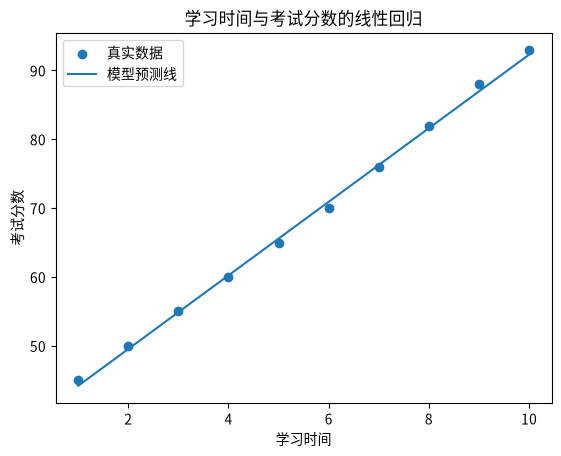

In [11]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 直接加载中文字体，避免 Matplotlib 显示方框
font_path = "/home/penglei/.local/share/fonts/NotoSansCJKsc-Regular.otf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

plt.scatter(df["study_hours"], df["score"], label="真实数据")

plt.plot(
    df["study_hours"],
    model.predict(df[["study_hours"]]),
    label="模型预测线"
)

plt.xlabel("学习时间")
plt.ylabel("考试分数")
plt.title("学习时间与考试分数的线性回归")
plt.legend()
plt.show()